# CARLA-NavSim Data Loading and Basic Visualization

This notebook covers the basics of loading and visualizing CARLA-NavSim cached training data.

## Contents
1. Setup and imports
2. Understanding the data structure
3. Loading single samples
4. Basic feature visualization
5. Basic target visualization

## 1. Setup and Imports

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pickle
import gzip
import torch
from PIL import Image
import io
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

## 2. Understanding the Data Structure

### Cached Data Organization
```
/workspace/navsim_workspace/exp/training_cache/
├── [sequence_name]/          # e.g., 2021.05.12.19.36.12_veh-35_00005_00204
│   ├── [token_id]/          # e.g., 0a678d2136b35b56
│   │   ├── transfuser_feature.gz
│   │   └── transfuser_target.gz
```

### Understanding Sequences and Tokens

In the CARLA-NavSim dataset, data is organized in a hierarchical structure:

#### Sequences
- **What**: A sequence represents a continuous driving scenario or trajectory
- **Naming**: Format like `2021.05.12.19.36.12_veh-35_00005_00204` indicates:
  - Timestamp: 2021.05.12.19.36.12
  - Vehicle ID: veh-35
  - Frame range: 00005 to 00204
- **Duration**: Typically contains 100-200 frames
- **Content**: Multiple consecutive observations from the same driving session

#### Tokens
- **What**: A token represents a single timestep or frame within a sequence
- **Naming**: Unique hash identifier like `0a678d2136b35b56`
- **Content**: One set of features (camera, LiDAR, status) and targets (trajectory, agents, BEV)
- **Frequency**: Sampled at 2Hz (0.5 second intervals)
- **Source**: https://github.com/autonomousvision/navsim/blob/main/docs/cache.md

#### Key Differences
1. **Temporal Scope**: 
   - Sequence = entire driving scenario (many seconds)
   - Token = single moment in time (0.5 seconds apart)

2. **Data Organization**:
   ```
   sequence/
   ├── token_1/
   │   ├── transfuser_feature.gz
   │   └── transfuser_target.gz
   ├── token_2/  (0.5 seconds later)
   │   ├── transfuser_feature.gz
   │   └── transfuser_target.gz
   └── ...
   ```

3. **Use in Training**:
   - Sequences group related data for temporal consistency
   - Tokens are individual training samples
   - Model sees one token at a time during training
   - Each token is 0.5 seconds apart from the next

### Data Format
**Features** (inputs to the model):
- `camera_feature`: RGB images from 3 front cameras
- `lidar_feature`: Bird's Eye View LiDAR histogram
- `status_feature`: Vehicle state (velocity, acceleration, driving command)

**Targets** (ground truth for training):
- `trajectory`: Future waypoints for next 4 seconds
- `agent_states`: Other vehicles' bounding boxes
- `agent_labels`: Valid agent mask
- `bev_semantic_map`: Segmentation map of the environment

In [2]:
# Define paths
base_cache_dir = Path("/workspace/navsim_workspace/exp/training_cache/")

# List available sequences
sequences = sorted([d for d in base_cache_dir.iterdir() if d.is_dir()])
print(f"Found {len(sequences)} sequences in cache")
print(f"\nFirst 5 sequences:")
for seq in sequences[:5]:
    tokens = list(seq.iterdir())
    print(f"  {seq.name} ({len(tokens)} tokens)")

Found 1192 sequences in cache

First 5 sequences:
  2021.05.12.19.36.12_veh-35_00005_00204 (6 tokens)
  2021.05.12.19.36.12_veh-35_00215_00405 (32 tokens)
  2021.05.12.19.36.12_veh-35_00416_00557 (48 tokens)
  2021.05.12.19.36.12_veh-35_00568_01168 (212 tokens)
  2021.05.12.19.36.12_veh-35_01179_01278 (5 tokens)


## 3. Loading Single Samples

In [3]:
def load_sample(sequence_path, token_idx=0):
    """Load a single feature-target pair from cache."""
    tokens = sorted([d for d in sequence_path.iterdir() if d.is_dir()])
    if token_idx >= len(tokens):
        print(f"Token index {token_idx} out of range (max: {len(tokens)-1})")
        return None, None
    
    token_path = tokens[token_idx]
    
    # Load features
    with gzip.open(token_path / "transfuser_feature.gz", 'rb') as f:
        features = pickle.load(f)
    
    # Load targets
    with gzip.open(token_path / "transfuser_target.gz", 'rb') as f:
        targets = pickle.load(f)
    
    return features, targets

# Load first sample from first sequence
features, targets = load_sample(sequences[0], token_idx=0)

# Display detailed feature information
print("=== TRANSFUSER FEATURES ===")
print(f"Available keys: {list(features.keys())}")
print("\n1. CAMERA FEATURE:")
print(f"   Shape: {features['camera_feature'].shape}")
print(f"   Data type: {features['camera_feature'].dtype}")
print(f"   Value range: [{features['camera_feature'].min():.3f}, {features['camera_feature'].max():.3f}]")
print(f"   Mean: {features['camera_feature'].mean():.3f}, Std: {features['camera_feature'].std():.3f}")
print(f"   Meaning: RGB image from 3 front-view cameras (CAM_F0, CAM_L0, CAM_R0) stitched horizontally")
print(f"   Dimensions: [3 channels (RGB), 256 height, 1024 width]")

print("\n2. LIDAR FEATURE:")
print(f"   Shape: {features['lidar_feature'].shape}")
print(f"   Data type: {features['lidar_feature'].dtype}")
print(f"   Value range: [{features['lidar_feature'].min():.0f}, {features['lidar_feature'].max():.0f}]")
print(f"   Non-zero elements: {(features['lidar_feature'] > 0).sum()} / {features['lidar_feature'].numel()} ({100*(features['lidar_feature'] > 0).sum()/features['lidar_feature'].numel():.2f}%)")
print(f"   Meaning: Bird's Eye View (BEV) histogram of LiDAR point cloud")
print(f"   Dimensions: [1 channel, 256x256 spatial grid]")
print(f"   Coverage: 64m x 64m area (0.25m per pixel resolution)")
print(f"   Source: transfuser_config.py line 25 - pixels_per_meter=4.0")

print("\n3. STATUS FEATURE:")
print(f"   Shape: {features['status_feature'].shape}")
print(f"   Data type: {features['status_feature'].dtype}")
print(f"   Values: {features['status_feature'].numpy()}")
print(f"   Structure: [left, straight, right, unknown, vx, vy, ax, ay]")
print(f"   - Driving command (one-hot): left={features['status_feature'][0]:.1f}, straight={features['status_feature'][1]:.1f}, right={features['status_feature'][2]:.1f}, unknown={features['status_feature'][3]:.1f}")
print(f"   - Velocity (vx, vy): ({features['status_feature'][4]:.2f}, {features['status_feature'][5]:.2f}) m/s")
print(f"   - Acceleration (ax, ay): ({features['status_feature'][6]:.2f}, {features['status_feature'][7]:.2f}) m/s²")
print(f"   Units: Standard SI units (m/s for velocity, m/s² for acceleration)")

print("\n=== TRANSFUSER TARGETS ===")
print(f"Available keys: {list(targets.keys())}")

print("\n1. TRAJECTORY:")
print(f"   Shape: {targets['trajectory'].shape}")
print(f"   Data type: {targets['trajectory'].dtype}")
traj_data = targets['trajectory'].numpy()
print(f"   X range: [{traj_data[:, 0].min():.2f}, {traj_data[:, 0].max():.2f}] meters")
print(f"   Y range: [{traj_data[:, 1].min():.2f}, {traj_data[:, 1].max():.2f}] meters")
print(f"   Heading range: [{traj_data[:, 2].min():.2f}, {traj_data[:, 2].max():.2f}] radians")
print(f"   Meaning: Future trajectory waypoints")
print(f"   Structure: [8 waypoints × (x, y, heading)]")
print(f"   Time horizon: 4 seconds (from transfuser_config.py)")
print(f"   Time intervals: 0.5 seconds (from transfuser_config.py)")
print(f"   Units: meters for position, radians for heading")

print("\n2. AGENT STATES:")
print(f"   Shape: {targets['agent_states'].shape}")
print(f"   Data type: {targets['agent_states'].dtype}")
agent_data = targets['agent_states'].numpy()
valid_agents = agent_data[targets['agent_labels'].numpy()]
if len(valid_agents) > 0:
    print(f"   X range (valid agents): [{valid_agents[:, 0].min():.2f}, {valid_agents[:, 0].max():.2f}] meters")
    print(f"   Y range (valid agents): [{valid_agents[:, 1].min():.2f}, {valid_agents[:, 1].max():.2f}] meters")
    print(f"   Length range: [{valid_agents[:, 3].min():.2f}, {valid_agents[:, 3].max():.2f}] meters")
    print(f"   Width range: [{valid_agents[:, 4].min():.2f}, {valid_agents[:, 4].max():.2f}] meters")
print(f"   Meaning: Other vehicles' bounding boxes in ego-centric coordinates")
print(f"   Structure: [30 slots × (x, y, heading, length, width)]")
print(f"   Max agents: 30 (from transfuser_config.py)")
print(f"   Units: meters for position/size, radians for heading")

print("\n3. AGENT LABELS:")
print(f"   Shape: {targets['agent_labels'].shape}")
print(f"   Data type: {targets['agent_labels'].dtype}")
print(f"   Valid agents: {targets['agent_labels'].sum()} / {len(targets['agent_labels'])}")
print(f"   Meaning: Boolean mask indicating which agent slots contain valid detections")
print(f"   Values: True (valid agent) or False (empty slot)")

print("\n4. BEV SEMANTIC MAP:")
print(f"   Shape: {targets['bev_semantic_map'].shape}")
print(f"   Data type: {targets['bev_semantic_map'].dtype}")
bev_data = targets['bev_semantic_map'].numpy()
print(f"   Value range: [{bev_data.min():.0f}, {bev_data.max():.0f}]")
print(f"   Unique values: {np.unique(bev_data).tolist()}")
print(f"   Meaning: Bird's Eye View semantic segmentation map")
print(f"   Spatial coverage: 64m × 32m (0.25m per pixel)")
print(f"   Categories (from transfuser_config.py):")
print(f"     0: Background (default)")
print(f"     1: Road (lanes + intersections)")
print(f"     2: Walkways")
print(f"     3: Lane centerlines")
print(f"     4: Static objects (barriers, cones, signs)")
print(f"     5: Vehicles")
print(f"     6: Pedestrians")

=== TRANSFUSER FEATURES ===
Available keys: ['camera_feature', 'lidar_feature', 'status_feature']

1. CAMERA FEATURE:
   Shape: torch.Size([3, 256, 1024])
   Data type: torch.float32
   Value range: [0.000, 1.000]
   Mean: 0.408, Std: 0.184
   Meaning: RGB image from 3 front-view cameras (CAM_F0, CAM_L0, CAM_R0) stitched horizontally
   Dimensions: [3 channels (RGB), 256 height, 1024 width]

2. LIDAR FEATURE:
   Shape: torch.Size([1, 256, 256])
   Data type: torch.float32
   Value range: [0, 1]
   Non-zero elements: 5698 / 65536 (8.69%)
   Meaning: Bird's Eye View (BEV) histogram of LiDAR point cloud
   Dimensions: [1 channel, 256x256 spatial grid]
   Coverage: 64m x 64m area (0.25m per pixel resolution)
   Source: transfuser_config.py line 25 - pixels_per_meter=4.0

3. STATUS FEATURE:
   Shape: torch.Size([8])
   Data type: torch.float32
   Values: [ 0.          1.          0.          0.          1.8030407  -0.03375518
  1.5873523  -0.13237587]
   Structure: [left, straight, right, u

## 4. Basic Feature Visualization

### Note on Status Feature Structure
The status feature order is determined in:
- **File**: `navsim/agents/diffusiondrive/transfuser_features.py`
- **Method**: `TransfuserFeatureBuilder._get_status_feature()`
- **Structure**: The method concatenates `[driving_command, ego_velocity, ego_acceleration]`
- **Final structure after one-hot encoding**: `[left, straight, right, unknown, velocity_x, velocity_y, acceleration_x, acceleration_y]`

The driving commands are integers (0=LEFT, 1=STRAIGHT, 2=RIGHT, 3=UNKNOWN) that get converted to one-hot encoding, where only one command is active (value=1) at a time.

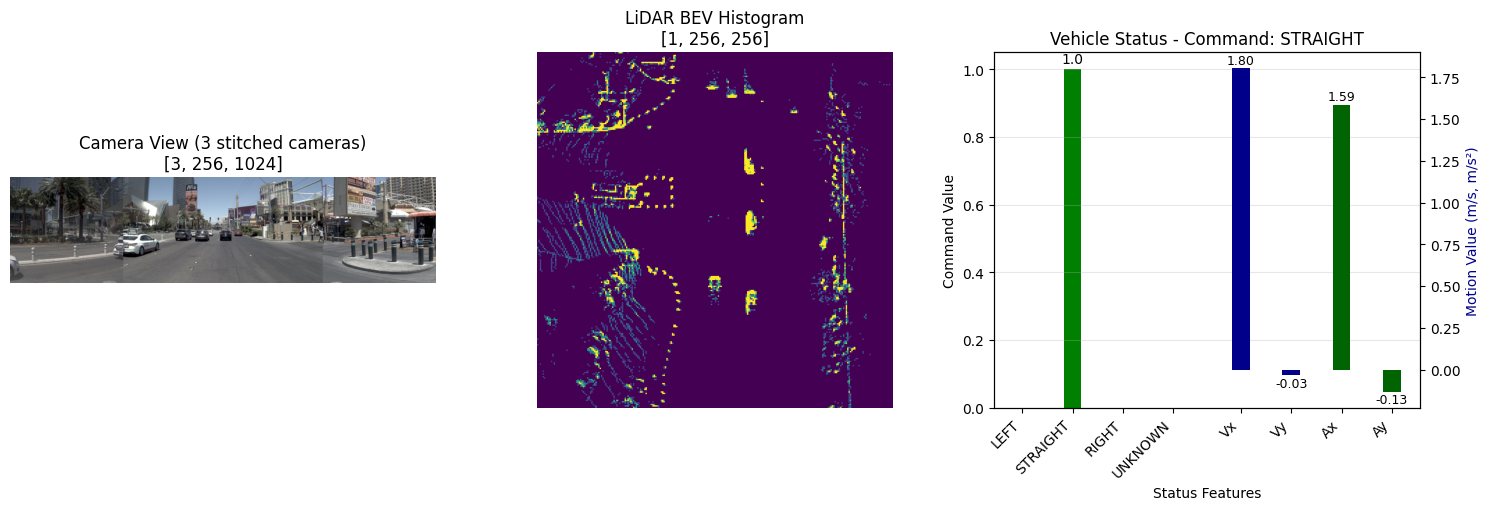

In [4]:
def visualize_features_basic(features, figsize=(15, 5)):
    """Basic visualization of input features."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # 1. Camera image
    camera_img = features['camera_feature'].numpy().transpose(1, 2, 0)
    axes[0].imshow(camera_img)
    axes[0].set_title('Camera View (3 stitched cameras)\n[3, 256, 1024]')
    axes[0].axis('off')
    
    # 2. LiDAR BEV
    lidar_img = features['lidar_feature'].numpy().squeeze(0)
    axes[1].imshow(lidar_img, cmap='viridis', origin='lower')
    axes[1].set_title('LiDAR BEV Histogram\n[1, 256, 256]')
    axes[1].axis('off')
    
    # 3. Status
    status = features['status_feature'].numpy()
    
    # Split into command and motion
    cmd_labels = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN']
    cmd_values = status[0:4]
    
    motion_labels = ['Vx', 'Vy', 'Ax', 'Ay']
    motion_values = status[4:8]
    
    # Create two bar groups
    x = np.arange(len(cmd_labels))
    width = 0.35
    
    # Command bars (one-hot encoded, one should be 1.0)
    active_cmd_idx = np.argmax(cmd_values)
    cmd_colors = ['lightgray'] * 4
    cmd_colors[active_cmd_idx] = ['orange', 'green', 'blue', 'red'][active_cmd_idx]
    
    bars1 = axes[2].bar(x - width/2, cmd_values, width, label='Commands', color=cmd_colors)
    
    # Motion values on secondary y-axis
    ax2 = axes[2].twinx()
    bars2 = ax2.bar(x + width/2 + 4, motion_values, width, label='Motion', 
                    color=['darkblue', 'darkblue', 'darkgreen', 'darkgreen'])
    
    # Labels and formatting
    axes[2].set_xlabel('Status Features')
    axes[2].set_ylabel('Command Value', color='black')
    ax2.set_ylabel('Motion Value (m/s, m/s²)', color='darkblue')
    
    axes[2].set_xticks(np.concatenate([x - width/2, x + width/2 + 4]))
    axes[2].set_xticklabels(cmd_labels + motion_labels, rotation=45, ha='right')
    axes[2].set_title(f'Vehicle Status - Command: {cmd_labels[active_cmd_idx]}')
    axes[2].grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars1, cmd_values):
        if val > 0.5:  # Only show for active command
            axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                        f'{val:.1f}', ha='center', va='bottom')
    
    for bar, val in zip(bars2, motion_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 if val > 0 else val - 0.01, 
                f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Visualize the loaded features
visualize_features_basic(features)

## 5. Basic Target Visualization

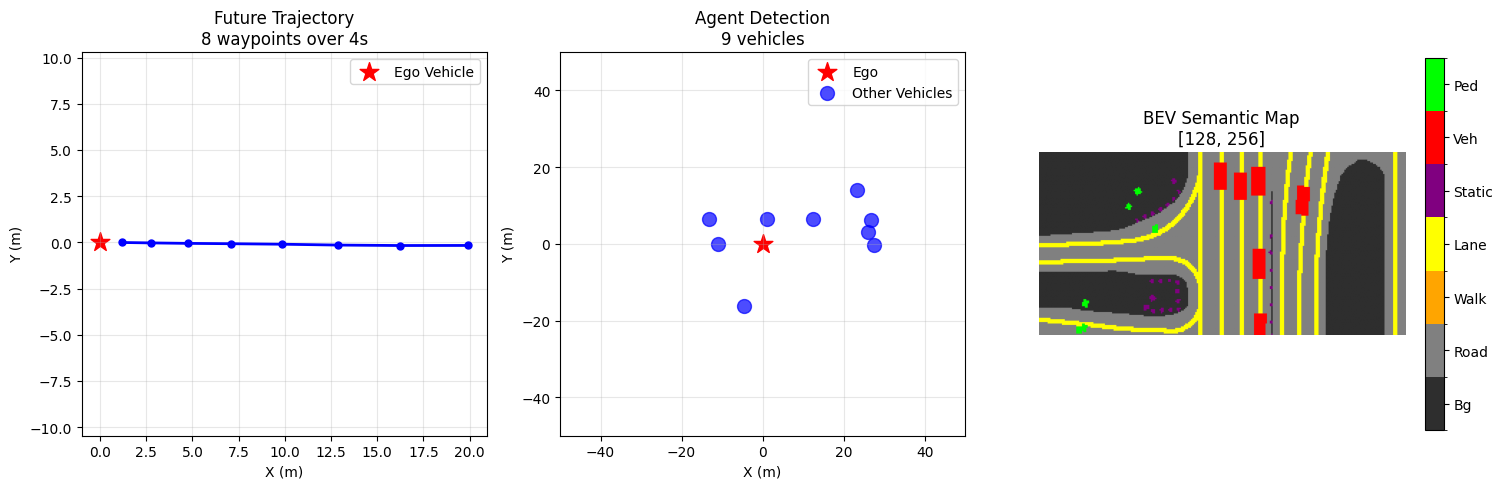

In [5]:
def visualize_targets_basic(targets, figsize=(15, 5)):
    """Basic visualization of target data."""
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # 1. Trajectory
    traj = targets['trajectory'].numpy()
    axes[0].plot(traj[:, 0], traj[:, 1], 'b.-', markersize=10, linewidth=2)
    axes[0].scatter(0, 0, c='red', s=200, marker='*', label='Ego Vehicle')
    axes[0].set_xlabel('X (m)')
    axes[0].set_ylabel('Y (m)')
    axes[0].set_title(f'Future Trajectory\n{len(traj)} waypoints over 4s')
    axes[0].grid(True, alpha=0.3)
    axes[0].axis('equal')
    axes[0].legend()
    
    # 2. Detected agents
    agent_states = targets['agent_states'].numpy()
    agent_labels = targets['agent_labels'].numpy()
    valid_agents = agent_states[agent_labels]
    
    axes[1].scatter(0, 0, c='red', s=200, marker='*', label='Ego')
    if len(valid_agents) > 0:
        axes[1].scatter(valid_agents[:, 0], valid_agents[:, 1], 
                       c='blue', s=100, alpha=0.7, label='Other Vehicles')
    axes[1].set_xlabel('X (m)')
    axes[1].set_ylabel('Y (m)')
    axes[1].set_title(f'Agent Detection\n{len(valid_agents)} vehicles')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(-50, 50)
    axes[1].set_ylim(-50, 50)
    axes[1].legend()
    
    # 3. BEV semantic map
    bev_map = targets['bev_semantic_map'].numpy()
    
    # Define colors for each category
    category_colors = {
        0: '#2E2E2E',    # Background
        1: '#808080',    # Road
        2: '#FFA500',    # Walkways
        3: '#FFFF00',    # Lane centerlines
        4: '#800080',    # Static objects
        5: '#FF0000',    # Vehicles
        6: '#00FF00'     # Pedestrians
    }
    
    colors = [category_colors[i] for i in range(7)]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(np.arange(8) - 0.5, 7)
    
    im = axes[2].imshow(bev_map, cmap=cmap, norm=norm, origin='lower')
    axes[2].set_title('BEV Semantic Map\n[128, 256]')
    axes[2].axis('off')
    
    # Add colorbar with labels
    cbar = plt.colorbar(im, ax=axes[2], ticks=range(7), fraction=0.046)
    cbar.ax.set_yticklabels(['Bg', 'Road', 'Walk', 'Lane', 'Static', 'Veh', 'Ped'])
    
    plt.tight_layout()
    plt.show()

# Visualize the loaded targets
visualize_targets_basic(targets)

## Summary

This notebook covered the basics of:
1. Understanding the CARLA-NavSim data structure
2. Loading cached feature and target data
3. Basic visualization of inputs and outputs

### Key Data Specifications

**Input Features:**
- Camera: 3 RGB channels, 256×1024 pixels (3 front cameras stitched)
- LiDAR: 1 channel, 256×256 BEV histogram (64m × 64m at 0.25m/pixel)
- Status: 8 values [vx, vy, ax, ay, stop, left, right, straight]

**Output Targets:**
- Trajectory: 8 waypoints × (x, y, heading) for 4 seconds at 0.5s intervals
- Agents: Up to 30 vehicles × (x, y, heading, length, width)
- BEV Map: 128×256 semantic segmentation (7 categories)

### Next Steps
- For temporal analysis and animations, see `02_temporal_analysis.ipynb`
- For scenario search and filtering, see `03_scenario_search.ipynb`